# Simple linear regression

## Import the relevant libraries

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.linear_model import LinearRegression

## Load the data

In [63]:
data = pd.read_csv("Simple+linear+regression.csv")
data.head()

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


## Create the regression

### Declare the dependent and independent variables

In [64]:
x = data['SAT'] #x is called input or feature
y = data['GPA'] #y is called output or target

Generally there are 3 types of MACHINE LEARNING, supervised, unsupervised and reinforcement learning

now we are sticking to supervised learning, we got input and output (input to produce output)

In our case, the SAT score is the INPUT, GPA is the output

## Checking shapes of our both variables

In [65]:
y.shape

(84,)

In [66]:
x.shape

(84,)

They are both vectors of length 84

### Regression with the variables shape are vectors

In [67]:
reg = LinearRegression()

In [68]:
#reg.fit(x,y)

### We have to convert x into 2D matrix to work with .fit()

In [69]:
x_matrix = x.values.reshape(-1,1)

In [70]:
reg.fit(x_matrix,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.275
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[952.32]


## Statistical side of the regression

### R-squared

In [71]:
reg.score(x_matrix,y)

0.40600391479679765

### Coefficients

In [72]:
reg.coef_

array([0.00165569])

### Intercept

In [73]:
reg.intercept_

np.float64(0.27504029966028076)

## Making predictions

In [76]:
reg.predict([[1740]])

array([3.15593751])

In [85]:
new_data = pd.DataFrame(data=[1740, 1760], columns=['SAT'])
new_data

,SAT
0,1740
1,1760


In [80]:
# new_data.rename(index={0: 'BOB', 1: 'ALICE'})

In [86]:
reg.predict(new_data)

D:\FastAPI\math-ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([3.15593751, 3.18905127])

In [92]:
new_data['Predicted_GPA'] = reg.predict(new_data[['SAT']])
new_data

D:\FastAPI\math-ml\.venv\Lib\site-packages\sklearn\utils\validation.py:2823: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


,SAT,Predicted_GPA
0,1740,3.155938
1,1760,3.189051


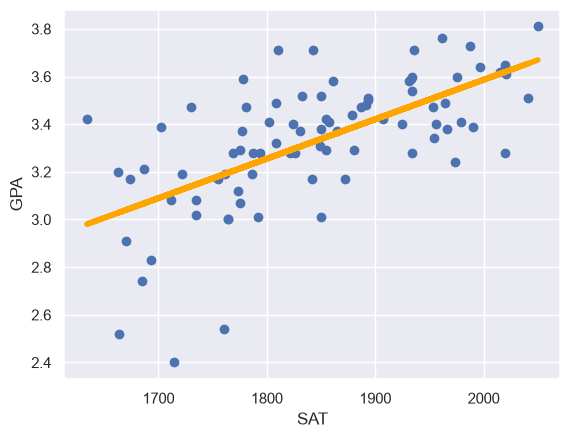

In [96]:
plt.scatter(x, y)
yhat = reg.coef_ * x_matrix + reg.intercept_

#yhat = 0.0017*x + 0.275

fig = plt.plot(x, yhat, lw=4, c='orange', label='Linear Regression line')
plt.xlabel('SAT')
plt.ylabel('GPA')
plt.show()